<a href="https://colab.research.google.com/github/Tinku679/employee-attrition-analysis-prediction/blob/main/HR_Analytics_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement

The objective of this project is to analyze employee data, identify factors related to employee attrition, and predict whether an employee will leave the company or stay.

In [1]:
# import the library requried for hr_ana
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#import the dataset
from google.colab import files

uploaded = files.upload()

Saving people.xls to people.xls


In [3]:
# run the dataset
df = pd.read_csv("people.xls")
df.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [4]:
# 'lastEvaluation' -> 'Performance'
# 'timeSpent.company' -> 'timeSpent_company'
df = df.rename(columns={'lastEvaluation' : 'Performance', 'timeSpent.company' : 'timeSpent_company'})


In [5]:
df

,satisfactoryLevel,Performance,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [6]:
# Handle the Null values and Duplicates
df.isnull().sum()

,0
satisfactoryLevel,0
Performance,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent_company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


In [7]:
df.duplicated().sum()

np.int64(3008)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
# Salary -> low, medium, high
# Show me the number of employee distribution according to the salary

In [11]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

In [12]:
df['salary'].value_counts()

,count
salary,
low,5740
medium,5261
high,990


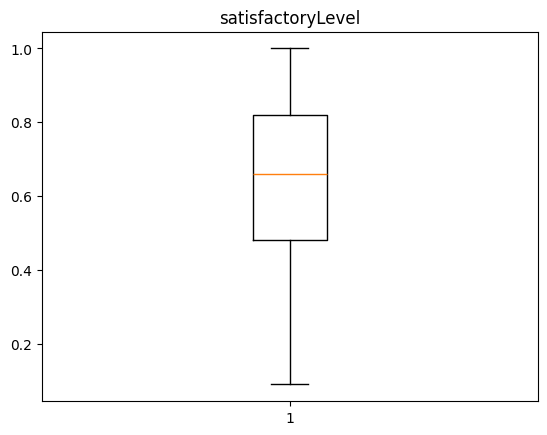

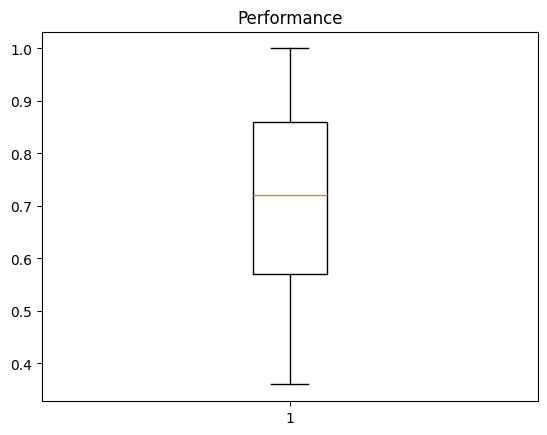

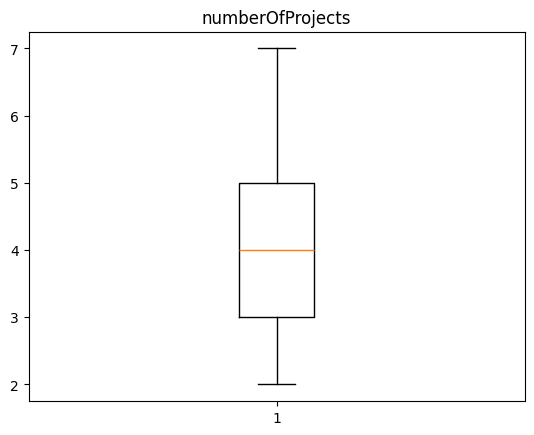

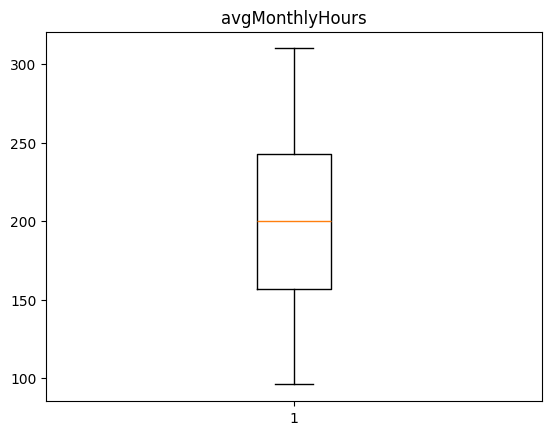

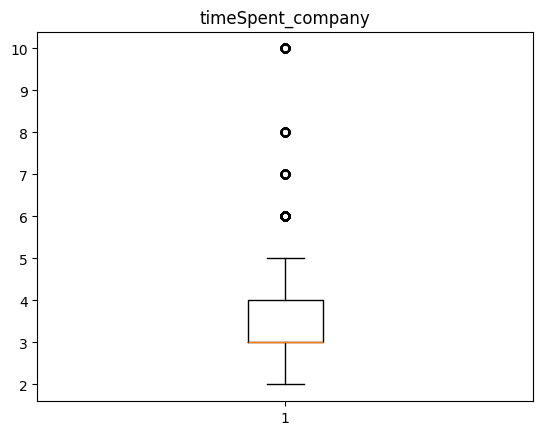

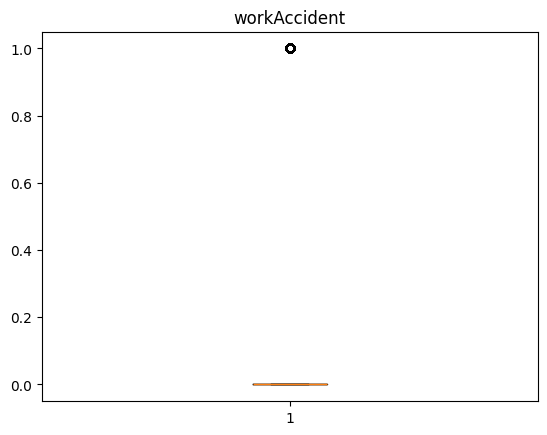

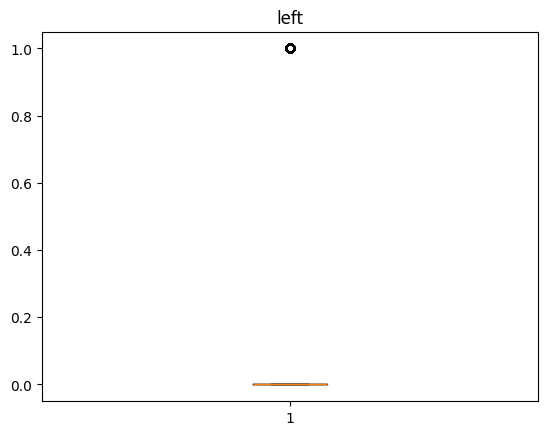

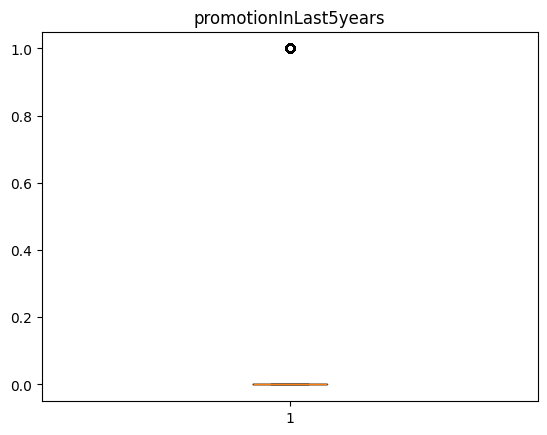

In [13]:
# Outliers were detected using the box plot.
# After validation, these values were found to be valid business observations,
# so they were retained and not removed.
for i in df.columns:
    if(df[i].dtype !='object'):
        plt.boxplot(df[i])
        plt.title(i)
        plt.show()

In [14]:
# Count Plot

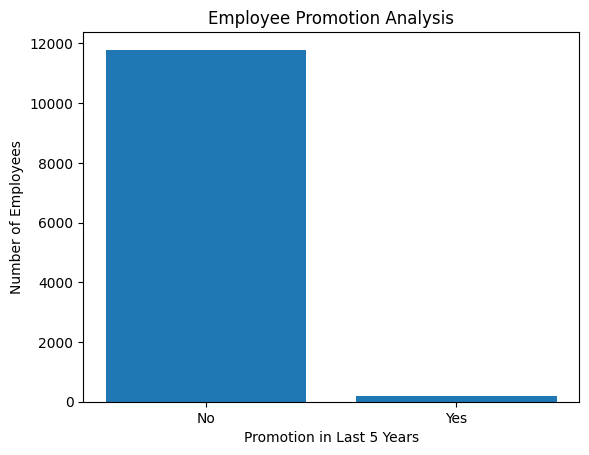

In [15]:
#How many employees received a promotion in the last 5 years, and how many did not? Visualize the result using a bar chart.
counts = df['promotionInLast5years'].value_counts().sort_index()
plt.bar(['No', 'Yes'], counts.values)
plt.xlabel('Promotion in Last 5 Years')
plt.ylabel('Number of Employees')
plt.title('Employee Promotion Analysis')
plt.show()

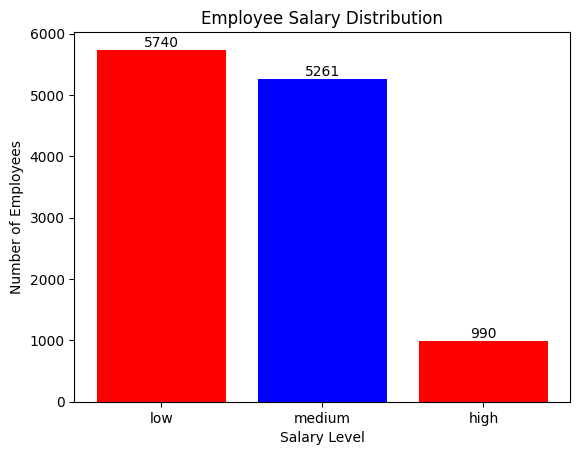

In [16]:
# What is the distribution of employees across different salary levels? Visualize the number of employees in each salary category using a bar chart.
salary_count = df['salary'].value_counts()

fig, ax = plt.subplots()

bars = ax.bar(
    salary_count.index,
    salary_count.values,
    color=["red", "blue"]
)

ax.bar_label(bars)

ax.set_xlabel('Salary Level')
ax.set_ylabel('Number of Employees')
ax.set_title('Employee Salary Distribution')

plt.show()

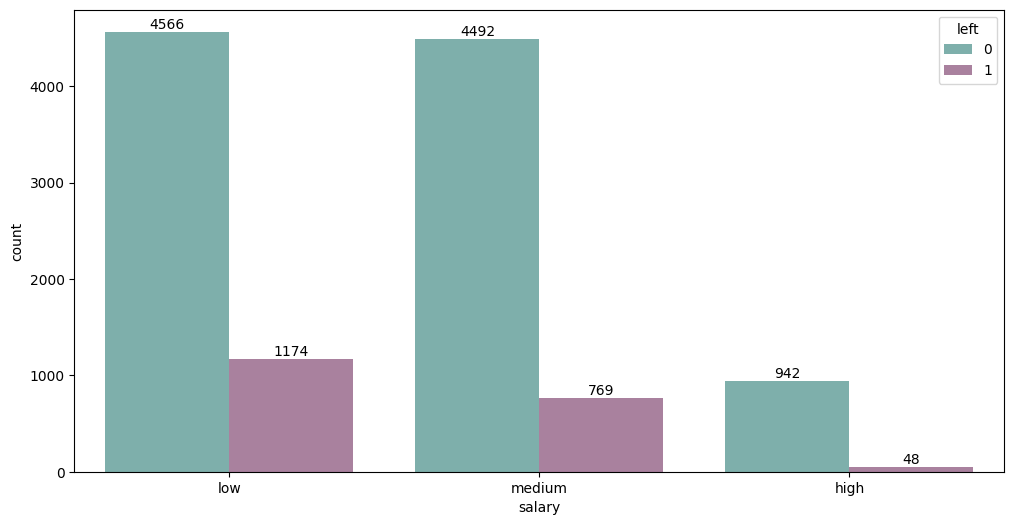

In [17]:
# Does employee attrition (left) vary across different salary levels?
plt.figure(figsize=(12,6))
fig =sns.countplot(data =df,x="salary",hue = "left",palette={0: "#76B7B2", 1: "#B07AA1"})
for constrain in fig.containers:
    fig.bar_label(constrain)
plt.show()

In [18]:
df.columns

Index(['satisfactoryLevel', 'Performance', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpent_company', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

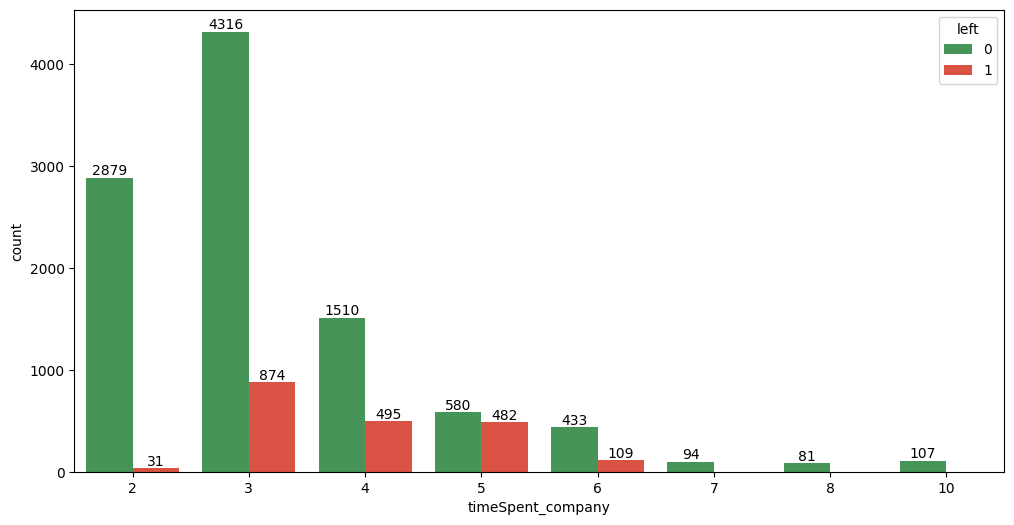

In [19]:
# Does employee attrition vary based on the time employees have spent in the company?
plt.figure(figsize=(12,6))
fig = sns.countplot(data =df , x="timeSpent_company",hue = "left",palette={0: "#39A14F", 1: "#F23E2B"})
for i in fig.containers:
    fig.bar_label(i)
plt.show()

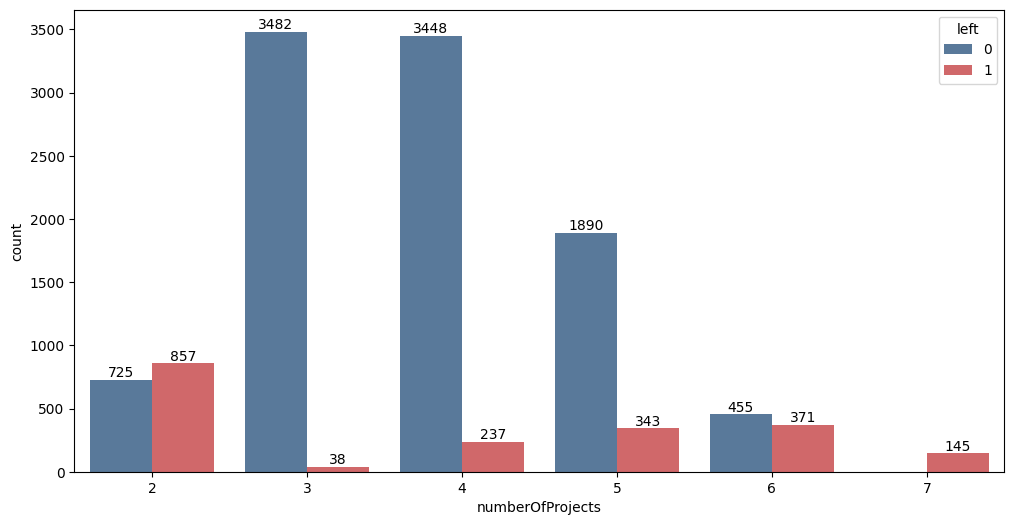

In [20]:
# Does employee attrition vary based on the number of projects handled?
plt.figure(figsize=(12,6))
fig = sns.countplot(data =df , x="numberOfProjects",hue = "left",palette={0: "#4E79A5", 1: "#E15759"})
for i in fig.containers:
    fig.bar_label(i)
plt.show()

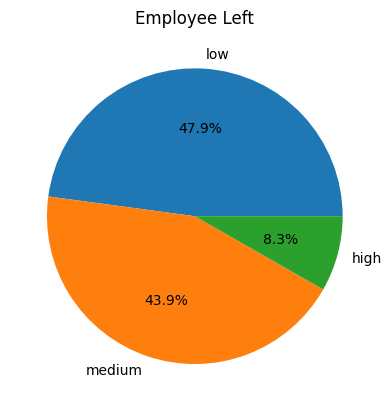

In [21]:

# What is the distribution of employees across different salary levels?
counts = df["salary"].value_counts()

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%"
)

plt.title("Employee Left")
plt.show()

In [22]:
df["workAccident"].value_counts()

,count
workAccident,
0,10141
1,1850


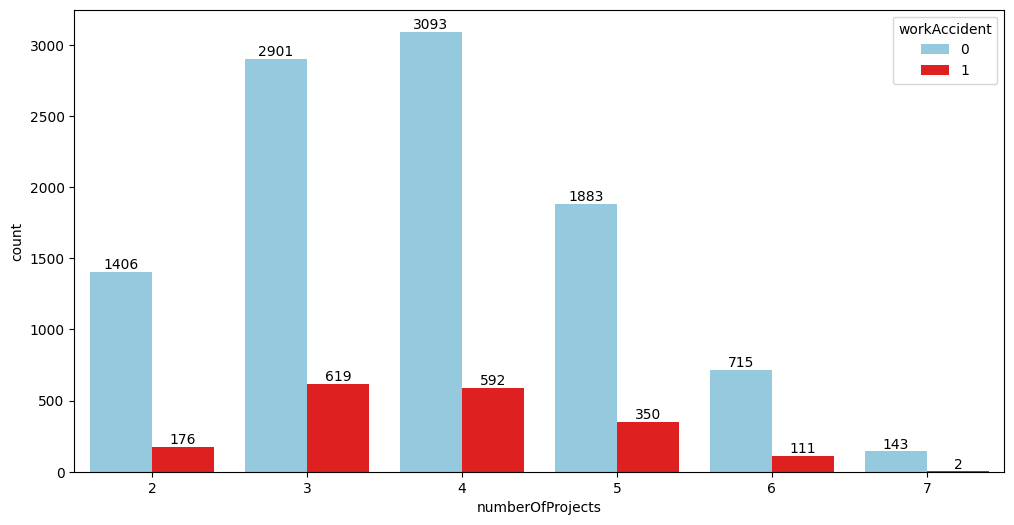

In [23]:
# Does the number of projects affect whether employees have a work accident?
plt.figure(figsize=(12,6))
fig = sns.countplot(data = df,x="numberOfProjects",hue = "workAccident", palette={0: "skyblue", 1: "red"})
for i in fig.containers:
    fig.bar_label(i)
plt.show()

# Objective:
# Build a machine learning model to predict employee attrition (left)
# based on employee performance, workload, experience, work accident,
# promotion history, department, and salary.


In [24]:
# Define the target variable and input features.
# axis 1 means remove the column and we do write axis 0 then remove rows


In [25]:
# x contains the feature of the model
x = df.drop("left",axis=1)

In [26]:

# y contains the target of the model
y = df["left"]

In [27]:
x

,satisfactoryLevel,Performance,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,0,sales,low
1,0.80,0.86,5,262,6,0,0,sales,medium
2,0.11,0.88,7,272,4,0,0,sales,medium
3,0.37,0.52,2,159,3,0,0,sales,low
4,0.41,0.50,2,153,3,0,0,sales,low
...,...,...,...,...,...,...,...,...,...
14992,0.30,0.88,5,245,4,0,0,hr,low
14995,0.99,0.83,4,274,2,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,sales,low


In [28]:
y

,left
0,1
1,1
2,1
3,1
4,1
...,...
14992,0
14995,0
14996,0
14997,0


In [29]:
df

,satisfactoryLevel,Performance,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14992,0.30,0.88,5,245,4,0,0,0,hr,low
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [30]:
# Import the libraries required for the model
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

In [31]:
# Use One-Hot Encoding because the categorical columns have no natural order
x = pd.get_dummies(x,columns=["dept","salary"],drop_first=True)

In [32]:
x

,satisfactoryLevel,Performance,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,promotionInLast5years,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,True,False,False,False,True
3,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,True,False,False,True,False
4,0.41,0.50,2,153,3,0,0,False,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14992,0.30,0.88,5,245,4,0,0,False,False,True,False,False,False,False,False,False,True,False
14995,0.99,0.83,4,274,2,0,0,False,False,False,False,False,False,True,False,False,True,False
14996,0.72,0.72,4,175,4,0,0,False,False,False,False,False,False,False,False,True,True,False
14997,0.24,0.91,5,177,5,0,0,False,False,False,False,False,False,True,False,False,True,False


In [33]:
y

,left
0,1
1,1
2,1
3,1
4,1
...,...
14992,0
14995,0
14996,0
14997,0


In [34]:
# Split the data into 80% training data and 20% testing data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on training data and transform it
scaled_x_train = scaler.fit_transform(x_train)

# Use the same scaler to transform test data
scaled_x_test = scaler.transform(x_test)

In [36]:
scaled_x_train

array([[-1.85986346, -1.28340458,  0.17343316, ..., -0.48506344,
         1.0395644 , -0.87958436],
       [-0.91188229, -1.46144915, -1.55136818, ..., -0.48506344,
         1.0395644 , -0.87958436],
       [ 1.43746235,  0.79378203,  0.17343316, ..., -0.48506344,
        -0.96194137,  1.13690062],
       ...,
       [ 0.48948118,  0.20030014,  1.03583383, ..., -0.48506344,
        -0.96194137,  1.13690062],
       [-0.747016  , -1.58014553, -1.55136818, ..., -0.48506344,
         1.0395644 , -0.87958436],
       [-0.0051177 ,  1.14987116,  0.17343316, ..., -0.48506344,
        -0.96194137,  1.13690062]])

In [37]:
scaled_x_test

array([[ 0.86043033,  1.32791573,  1.03583383, ..., -0.48506344,
         1.0395644 , -0.87958436],
       [-0.41728342,  1.09052297, -0.68896751, ..., -0.48506344,
        -0.96194137,  1.13690062],
       [-1.73621375,  0.14095195,  1.03583383, ..., -0.48506344,
        -0.96194137, -0.87958436],
       ...,
       [ 1.39624577, -0.21513718, -0.68896751, ...,  2.061586  ,
        -0.96194137,  1.13690062],
       [ 0.4482646 , -0.27448537,  0.17343316, ..., -0.48506344,
        -0.96194137,  1.13690062],
       [ 0.98408005,  0.25964833,  0.17343316, ..., -0.48506344,
         1.0395644 , -0.87958436]])

In [38]:
# Create a Logistic Regression classification model
model = LogisticRegression()

# Train the model using the scaled training features and target values
model.fit(scaled_x_train, y_train)

LogisticRegression()

In [39]:
y_pred = model.predict(scaled_x_test)

In [40]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Convert accuracy from decimal to percentage and display it
print("Accuracy:", accuracy * 100)

Accuracy: 83.40975406419341


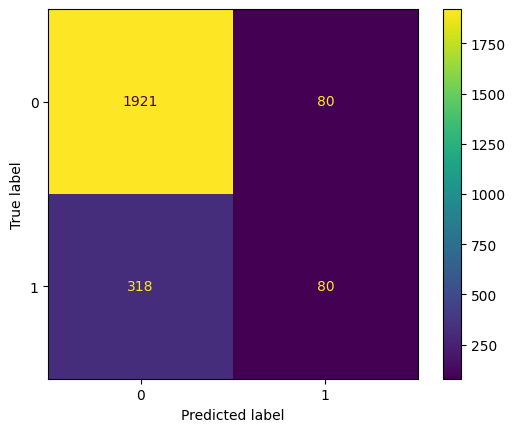

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix using actual and predicted values
cm = confusion_matrix(y_test, y_pred)

# Create a display object for the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix
disp.plot()

# Display the plot
plt.show()

In [42]:
# Generate and display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2001
           1       0.50      0.20      0.29       398

    accuracy                           0.83      2399
   macro avg       0.68      0.58      0.60      2399
weighted avg       0.80      0.83      0.80      2399



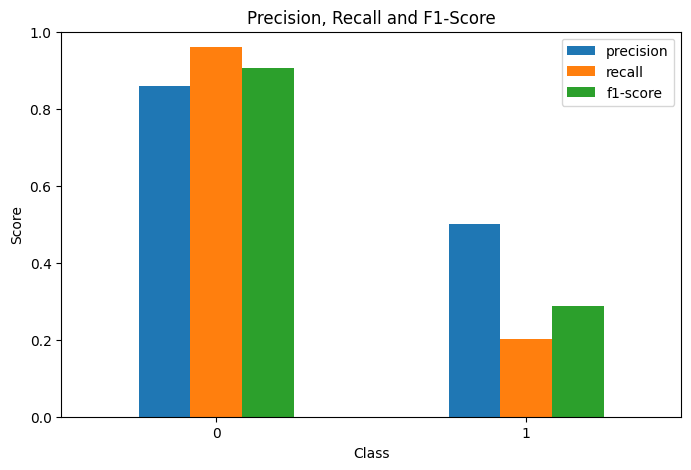

In [45]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Create classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert dictionary into DataFrame
df_report = pd.DataFrame(report).T

# Select precision, recall, and F1-score for classes 0 and 1
df_report.loc[["0", "1"], ["precision", "recall", "f1-score"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Precision, Recall and F1-Score")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

**After building the Logistic Regression model, I evaluated its performance using accuracy,
confusion matrix, precision, recall, and F1-score.
The model gives a reasonable overall performance, but the minority class is not being identified effectively,
particularly in terms of recall. Therefore, I would not stop at the initial model.
My next step would be to improve the model by addressing class imbalance, tuning hyperparameters,
and comparing it with other classification algorithms such as Decision Tree, Random Forest,
and Logistic Regression. I would then select the model based on appropriate evaluation metrics,
 especially recall and F1-score for the minority class.**
